# **Обучение StyleGAN_NADA**

## Установка необходимых библиотек и подготовка окружения

In [1]:
# Установка зависимостей
!pip install -q ftfy regex tqdm ninja gdown
!pip install -q git+https://github.com/openai/CLIP.git

# Импорт нужных библиотек
import os
import sys
import torch
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np

project_dir = os.path.abspath(".")
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# Клонирование репозитория StyleGAN2
if not os.path.exists("stylegan2_pytorch"):
    !git clone https://github.com/rosinality/stylegan2-pytorch.git stylegan2_pytorch

Cloning into 'stylegan2_pytorch'...
remote: Enumerating objects: 395, done.
remote: Total 395 (delta 0), reused 0 (delta 0), pack-reused 395 (from 1)
Receiving objects: 100% (395/395), 122.51 MiB | 16.96 MiB/s, done.
Resolving deltas: 100% (205/205), done.


In [3]:
# Клонирование репозитория
if not os.path.exists("stylegan-nada"):
    !git clone https://github.com/Astral194/stylegan-nada.git stylegan_nada

Cloning into 'dls'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 62 (delta 31), reused 50 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 21.45 KiB | 21.45 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [4]:
import sys
sys.path.append('/content/stylegan-nada')
sys.path.append('/content/stylegan2_pytorch')

from utils.loss import CLIPLoss

In [5]:
# Будем работать с конкретным сидом
torch.manual_seed(345)

In [6]:
# Зададим девайс: cuda или cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Зададим сид
seed = 3456
torch.manual_seed(seed)

## Основная идея статьи
Основная идея StyleGAN-NADA (StyleGAN-NADA: CLIP-Guided Domain Adaptation of Image Generators) заключается в адаптации предобученного генератора StyleGAN к новому домену без использования обучающих изображений целевого домена.

Вместо набора изображений используется только текстовое описание желаемого стиля (например, "zombie", "anime", "pencil sketch"). Для обучения применяется модель CLIP, которая преобразует изображения и текст в единое пространство признаков. Генератор оптимизируется таким образом, чтобы направление изменения признаков сгенерированного изображения совпадало с направлением изменения между исходным и целевым текстовыми описаниями (Directional CLIP Loss).

В результате получается генератор, способный синтезировать изображения в новом домене, сохраняя при этом содержание, структуру и разнообразие изображений исходного генератора, не требуя ни одного изображения из целевого домена.

Для работы со StyleGAN-2 нам для начала нужно скачать модель. Для скачивания мы используем следующий код:

In [7]:
!gdown 1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT
!gdown 1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL

Downloading...
From (original): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT
From (redirected): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT&confirm=t&uuid=d1943d40-e999-4f78-bf88-82365d7fff3e
To: /content/stylegan2-ffhq-config-f.pt
100% 381M/381M [00:11<00:00, 31.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL
From (redirected): https://drive.google.com/uc?id=1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL&confirm=t&uuid=001df634-9d36-4295-ad88-a4ec04670edf
To: /content/model_ir_se50.pth
100% 175M/175M [00:06<00:00, 26.8MB/s]


In [8]:
# Зададим девайс: cuda или cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Зададим сид
seed = 3456
torch.manual_seed(seed)

# Загрузка модели генератора StyleGAN2
from model import Generator
latent_dim = 512
generator = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
state_dict = torch.load('stylegan2-ffhq-config-f.pt', map_location=device)
generator.load_state_dict(state_dict['g_ema'])
generator.eval()

print("Генератор StyleGAN2 загружены.")

Генератор StyleGAN2 загружены.


## Импортируем cliploss


In [9]:
clip_loss = CLIPLoss()

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 167MiB/s]


## Инициализация текстовой пары
Определим текстовые запросы $t$ и $t'$

In [10]:
source_text = "photo"
target_text = "pencil sketch"

In [11]:
# Подготовим папку для сохранения результатов
import os
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

In [12]:
%matplotlib inline

## Обучение

Загрузим второй генератор, чтобы сравнить генерацию обычного изображения с таргетом.

In [13]:
generator_clean = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
generator_clean.load_state_dict(state_dict['g_ema'])
generator_clean.eval()

Generator(
  (style): Sequential(
    (0): PixelNorm()
    (1): EqualLinear(512, 512)
    (2): EqualLinear(512, 512)
    (3): EqualLinear(512, 512)
    (4): EqualLinear(512, 512)
    (5): EqualLinear(512, 512)
    (6): EqualLinear(512, 512)
    (7): EqualLinear(512, 512)
    (8): EqualLinear(512, 512)
  )
  (input): ConstantInput()
  (conv1): StyledConv(
    (conv): ModulatedConv2d(512, 512, 3, upsample=False, downsample=False)
    (noise): NoiseInjection()
    (activate): FusedLeakyReLU()
  )
  (to_rgb1): ToRGB(
    (conv): ModulatedConv2d(512, 3, 1, upsample=False, downsample=False)
  )
  (convs): ModuleList(
    (0): StyledConv(
      (conv): ModulatedConv2d(512, 512, 3, upsample=True, downsample=False)
      (noise): NoiseInjection()
      (activate): FusedLeakyReLU()
    )
    (1): StyledConv(
      (conv): ModulatedConv2d(512, 512, 3, upsample=False, downsample=False)
      (noise): NoiseInjection()
      (activate): FusedLeakyReLU()
    )
    (2): StyledConv(
      (conv): Modul

/content/stylegan2_pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.11.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


Step 0 Total loss: 0.9727 CLIP: 0.9727 L2: 0.0000


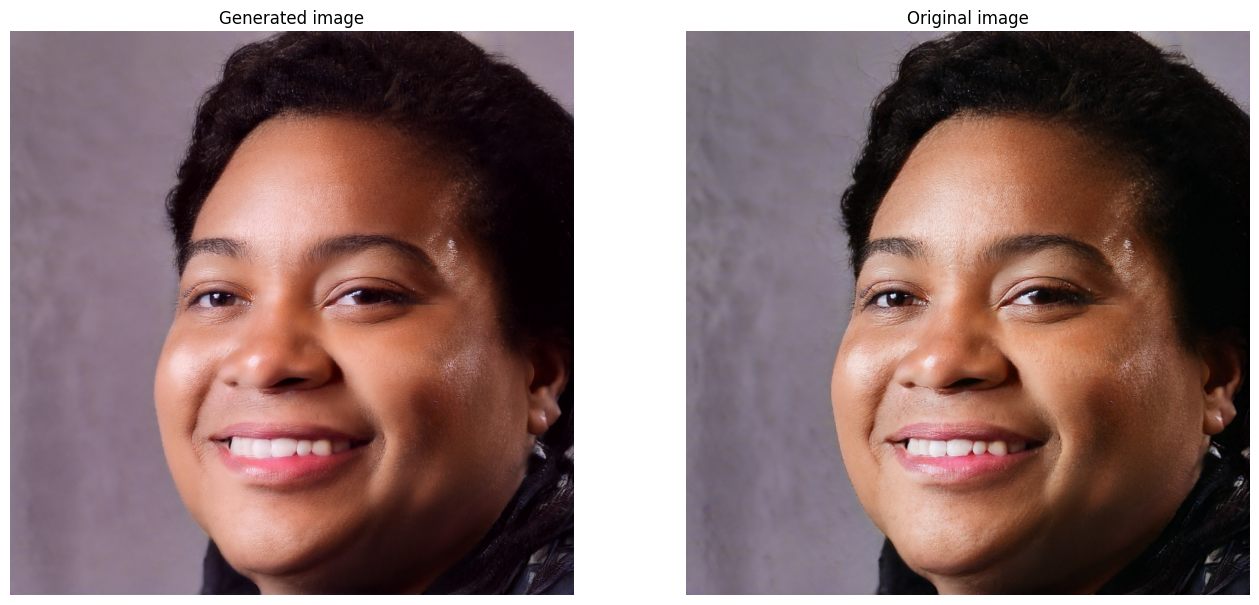

Step 200 Total loss: 0.8285 CLIP: 0.8032 L2: 0.0361


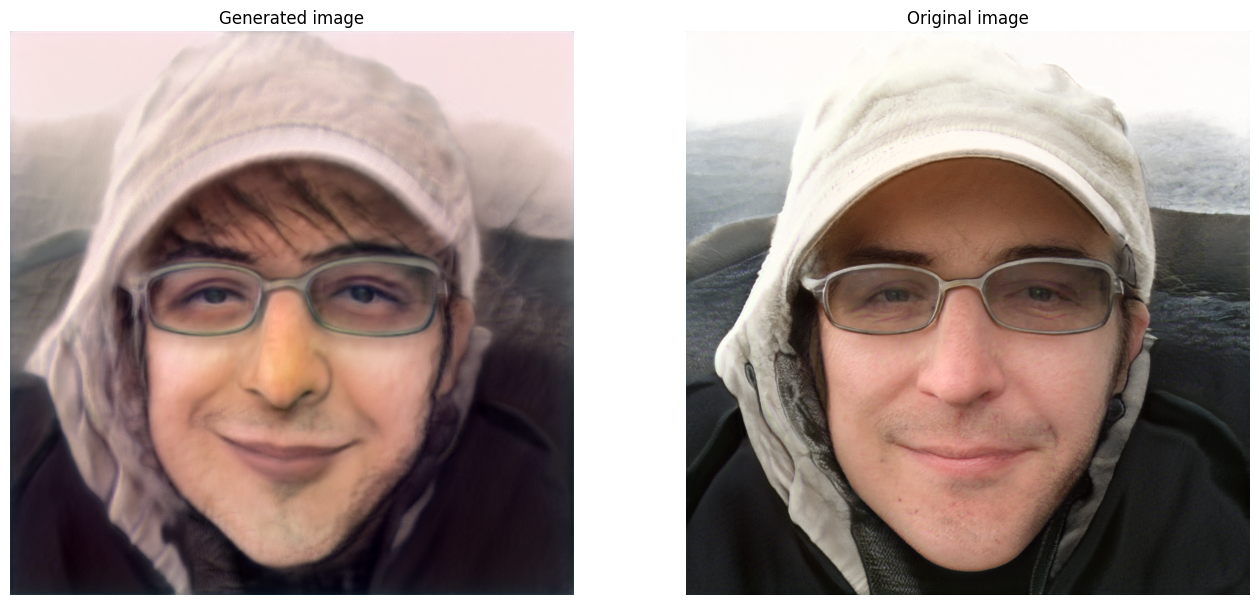

Step 400 Total loss: 0.7407 CLIP: 0.7139 L2: 0.0383


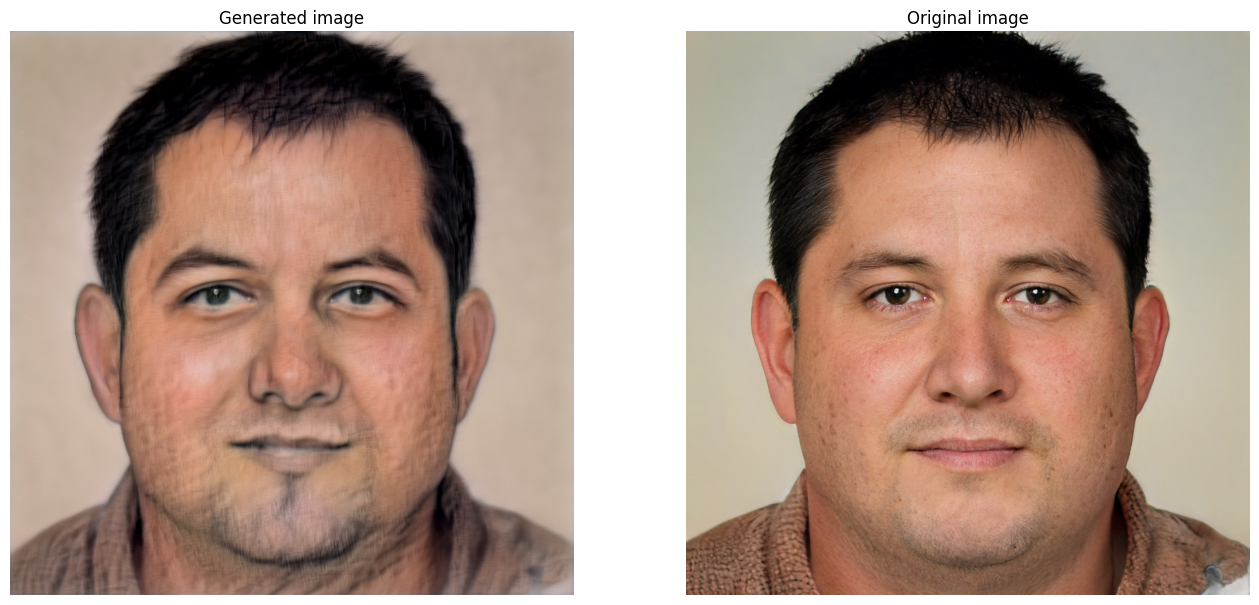

Step 600 Total loss: 0.6883 CLIP: 0.6704 L2: 0.0256


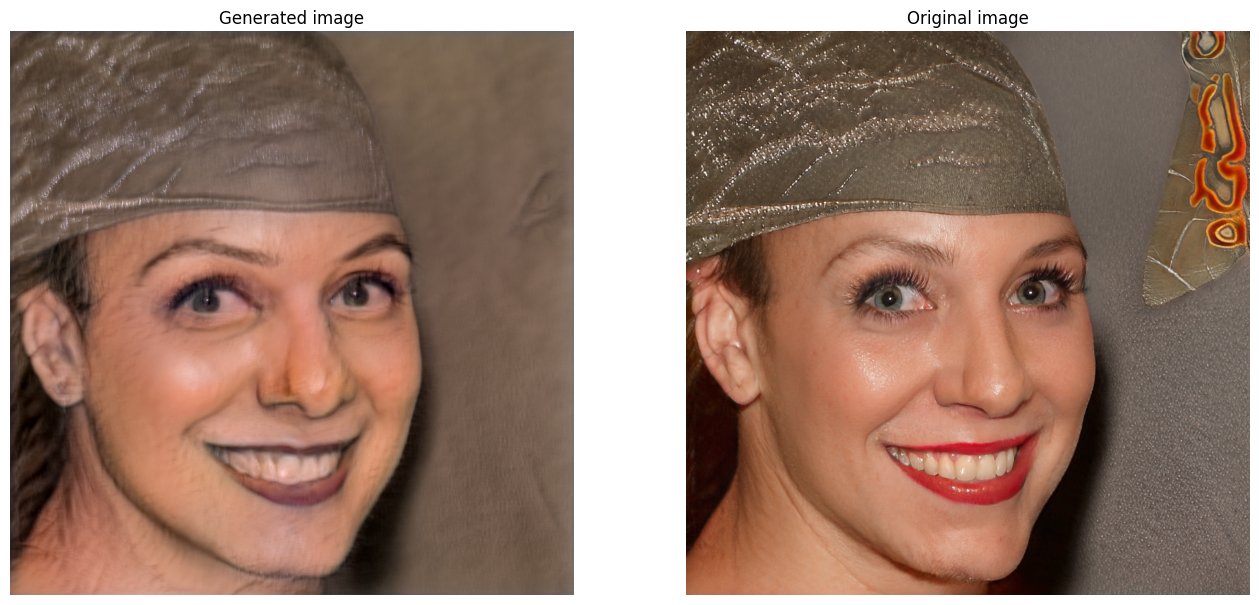

Step 800 Total loss: 0.7114 CLIP: 0.6777 L2: 0.0481


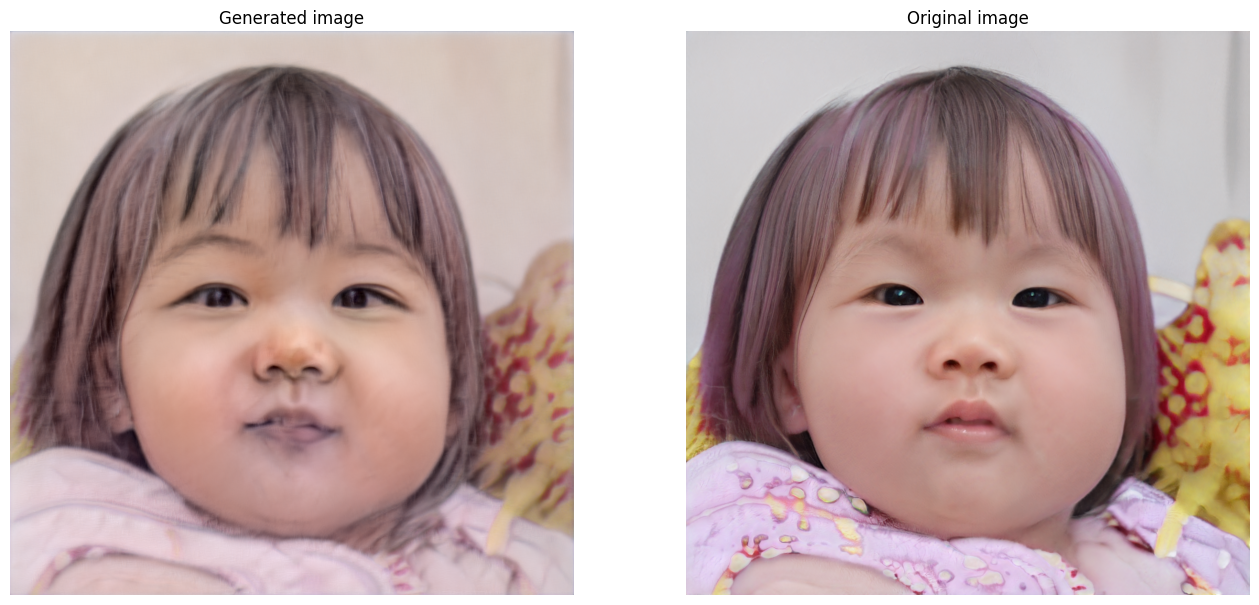

Step 1000 Total loss: 0.6955 CLIP: 0.6787 L2: 0.0240


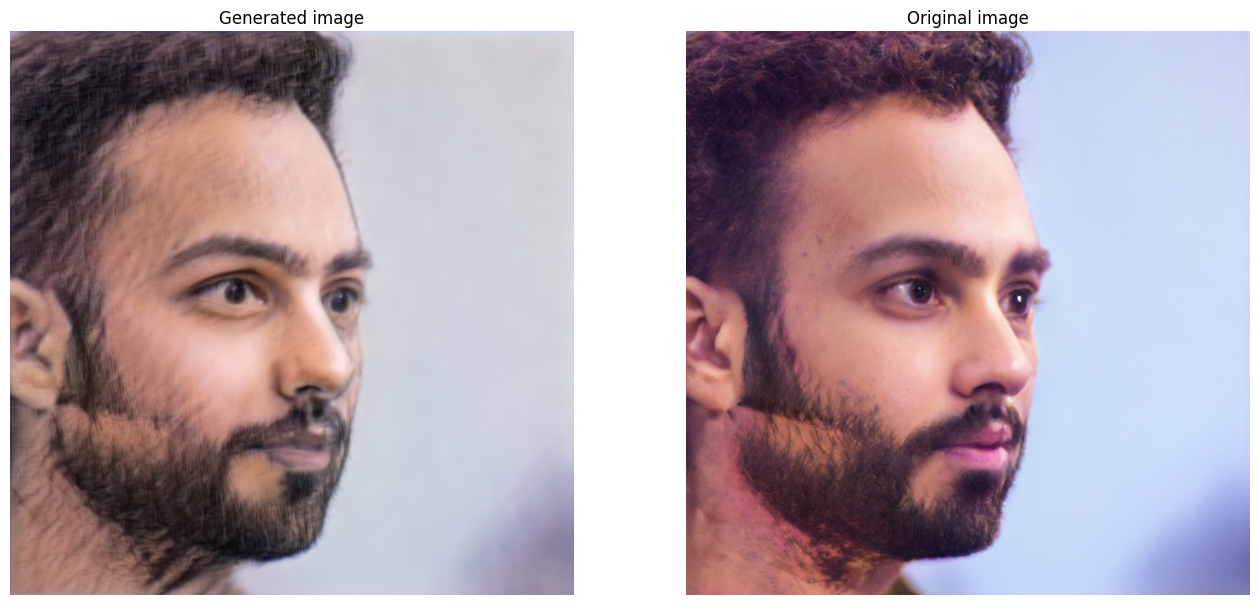

In [14]:
from stylegan_nada.utils.trainer import StyleGAN2NADATrainer

generator.train()

optimizer = torch.optim.Adam(generator.parameters(), lr=5e-3)

scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.997
)

trainer = StyleGAN2NADATrainer(
    generator=generator,
    generator_clean=generator_clean,
    clip_loss=clip_loss,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    source_text=source_text,
    target_text=target_text,
    num_steps=1000,
    l2_lambda=0.7,
    latent_dim=512,
    visualize_every=200
)

losses = trainer.train()

Визуализируем лоссы в зависимости от step

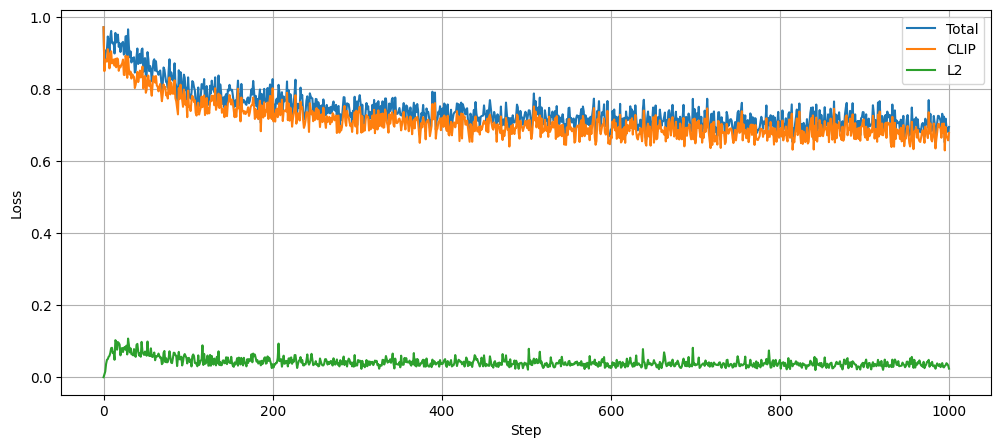

In [15]:
trainer.plot_losses()

Сохраним результаты!

In [16]:
torch.save(
    generator.state_dict(),
    os.path.join(save_dir, "baseline.pt")
)

In [17]:
from google.colab import files

files.download('/content/results/baseline.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>